# Pipeline de Modelagem Preditiva — Random Forest

Este notebook implementa a pipeline completa de modelagem preditiva para prever o número de internações por doenças respiratórias no dia D0 no Rio de Janeiro, utilizando features temporais, sazonais e atmosféricas.

**Modelo:** Random Forest Regressor

**Entrada:** `Data/GoldData/modelDataset.parquet`

**Etapas principais:**
1. Carregamento e inspeção
2. Preparação e divisão temporal
3. Baselines
4. Treinamento com diferentes estratégias de alvo
5. Ajuste de hiperparâmetros
6. Avaliação final e diagnósticos
7. Importância das features
8. Consolidação e salvamento

## 1. Imports e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path('../../Data')
OUTPUT_DIR = BASE_DIR / 'GoldData' / 'ModelResults'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup concluído.')

Setup concluído.


## 2. Carregamento e Inspeção do Dataset

In [2]:
PATH_DATASET = BASE_DIR / 'GoldData' / 'modelDataset.parquet'
df = pd.read_parquet(PATH_DATASET)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["data"].min().date()} a {df["data"].max().date()}')
print(f'\nColunas ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}, NaN={df[col].isnull().sum()}')

display(df.head())

Shape: (2192, 31)
Período: 2012-12-31 a 2018-12-31

Colunas (31):
  data: datetime64[us], NaN=0
  target: int64, NaN=0
  lag_1: float64, NaN=0
  lag_2: float64, NaN=0
  lag_3: float64, NaN=0
  lag_7: float64, NaN=0
  lag_14: float64, NaN=0
  lag_21: float64, NaN=0
  lag_28: float64, NaN=0
  lag_30: float64, NaN=0
  lag_365: float64, NaN=0
  rolling_mean_7: float64, NaN=0
  rolling_mean_14: float64, NaN=0
  rolling_mean_30: float64, NaN=0
  rolling_std_7: float64, NaN=0
  rolling_std_30: float64, NaN=0
  dia_semana: int32, NaN=0
  fim_de_semana: int64, NaN=0
  mes: int32, NaN=0
  semana_epidemiologica: int64, NaN=0
  estacao: int64, NaN=0
  dummy_periodo_pico_sazonal: int64, NaN=0
  o3_ma_120d_shift_1d: float64, NaN=0
  no_ma_30d_shift_1d: float64, NaN=0
  co_ma_120d_shift_1d: float64, NaN=0
  so2_ma_150d_shift_21d: float64, NaN=0
  nox_ma_21d_shift_1d: float64, NaN=0
  no2_lag0: float64, NaN=0
  pm2_5_ma_30d_shift_1d: float64, NaN=0
  temp_ma_14d_shift_1d: float64, NaN=0
  ur_ma_60d_sh

,data,target,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,lag_30,...,dummy_periodo_pico_sazonal,o3_ma_120d_shift_1d,no_ma_30d_shift_1d,co_ma_120d_shift_1d,so2_ma_150d_shift_21d,nox_ma_21d_shift_1d,no2_lag0,pm2_5_ma_30d_shift_1d,temp_ma_14d_shift_1d,ur_ma_60d_shift_1d
0,2012-12-31,247,170.0,421.0,527.0,184.0,311.0,481.0,426.0,368.0,...,0,36.802350,11.029467,0.360033,4.477627,52.592095,28.620,18.451433,31.270214,73.523417
1,2013-01-01,403,247.0,170.0,421.0,236.0,276.0,404.0,535.0,382.0,...,0,36.854375,11.035400,0.360292,4.522940,52.468524,24.190,18.895867,31.328286,73.421467
2,2013-01-02,520,403.0,247.0,170.0,587.0,377.0,404.0,365.0,426.0,...,0,36.907775,10.960133,0.360925,4.544213,50.579143,16.275,19.049367,31.519500,72.901867
3,2013-01-03,442,520.0,403.0,247.0,424.0,400.0,228.0,449.0,535.0,...,0,37.018517,10.910600,0.361850,4.558227,49.133333,22.320,18.846567,31.551357,72.813083
4,2013-01-04,442,442.0,520.0,403.0,527.0,415.0,339.0,423.0,365.0,...,0,36.921233,10.887533,0.361983,4.584013,47.653571,21.395,18.514967,31.102786,73.107600


## 3. Preparação para Modelagem

Separa a coluna de data (referência temporal), a variável alvo e as features preditoras. A coluna `data` não entra no modelo — serve apenas para ordenação e divisão temporal.

In [3]:
# Coluna alvo e colunas que não são features
TARGET_COL = 'target'
NON_FEATURE_COLS = ['data', 'target']

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
dates = df['data']
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nAlvo: {TARGET_COL}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nNaN em X: {X.isnull().sum().sum()}')
print(f'NaN em y: {y.isnull().sum()}')

# Verifica que todas as features são numéricas
assert X.select_dtypes(include='number').shape[1] == X.shape[1], \
    'Existem colunas não numéricas em X!'
print('\nTodas as features são numéricas. OK.')

Features (29): ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30', 'dia_semana', 'fim_de_semana', 'mes', 'semana_epidemiologica', 'estacao', 'dummy_periodo_pico_sazonal', 'o3_ma_120d_shift_1d', 'no_ma_30d_shift_1d', 'co_ma_120d_shift_1d', 'so2_ma_150d_shift_21d', 'nox_ma_21d_shift_1d', 'no2_lag0', 'pm2_5_ma_30d_shift_1d', 'temp_ma_14d_shift_1d', 'ur_ma_60d_shift_1d']

Alvo: target
X shape: (2192, 29)
y shape: (2192,)

NaN em X: 0
NaN em y: 0

Todas as features são numéricas. OK.


## 4. Divisão Temporal

Divisão cronológica: **treino → validação → teste**.

A série cobre 2012-12-31 a 2018-12-31 (~6 anos). Proporção:
- **Treino:** ~70% — primeiros ~4 anos
- **Validação:** ~15% — ~1 ano seguinte  
- **Teste:** ~15% — último ~1 ano

Nenhuma aleatoriedade: divisão puramente temporal.

In [4]:
# Datas de corte para divisão temporal
TRAIN_END = pd.Timestamp('2016-12-31')
VAL_END = pd.Timestamp('2017-12-31')

mask_train = dates <= TRAIN_END
mask_val = (dates > TRAIN_END) & (dates <= VAL_END)
mask_test = dates > VAL_END

X_train, y_train, dates_train = X[mask_train], y[mask_train], dates[mask_train]
X_val, y_val, dates_val = X[mask_val], y[mask_val], dates[mask_val]
X_test, y_test, dates_test = X[mask_test], y[mask_test], dates[mask_test]

print('Divisão temporal:')
for name, d, x_s in [('Treino', dates_train, X_train),
                      ('Validação', dates_val, X_val),
                      ('Teste', dates_test, X_test)]:
    print(f'  {name}: {d.min().date()} a {d.max().date()} '
          f'({len(x_s)} dias, {len(x_s)/len(X)*100:.1f}%)')

# Verifica que não há sobreposição
assert dates_train.max() < dates_val.min(), 'Sobreposição treino-validação!'
assert dates_val.max() < dates_test.min(), 'Sobreposição validação-teste!'
print('\nSem sobreposição entre conjuntos. OK.')

Divisão temporal:
  Treino: 2012-12-31 a 2016-12-31 (1462 dias, 66.7%)
  Validação: 2017-01-01 a 2017-12-31 (365 dias, 16.7%)
  Teste: 2018-01-01 a 2018-12-31 (365 dias, 16.7%)

Sem sobreposição entre conjuntos. OK.


## 5. Modelos Baseline

Referências simples para calibrar a expectativa de desempenho:
- **Persistência (lag_1):** valor de internações do dia anterior
- **Média móvel 7 dias:** média dos últimos 7 dias
- **Mesmo dia da semana anterior (lag_7):** valor de 7 dias atrás

In [5]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Evita divisão por zero
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100


def evaluate(y_true, y_pred, label=''):
    """Calcula e retorna métricas de regressão."""
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }
    if label:
        print(f'\n--- {label} ---')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    return metrics


# Baselines avaliados no conjunto de validação
baselines = {}

# Baseline 1: Persistência (lag_1) — previsão = internações do dia anterior
baselines['Persistência (lag_1)'] = evaluate(
    y_val.values, X_val['lag_1'].values, 'Persistência (lag_1)'
)

# Baseline 2: Média móvel 7 dias
baselines['Média Móvel 7d'] = evaluate(
    y_val.values, X_val['rolling_mean_7'].values, 'Média Móvel 7 dias'
)

# Baseline 3: Mesmo dia da semana anterior (lag_7)
baselines['Lag 7 (mesmo dia semana)'] = evaluate(
    y_val.values, X_val['lag_7'].values, 'Lag 7 (mesmo dia semana)'
)

df_baselines = pd.DataFrame(baselines).T
print('\n=== Resumo Baselines (Validação) ===')
display(df_baselines.round(4))


--- Persistência (lag_1) ---
  MAE: 73.7178
  RMSE: 93.1991
  R²: -0.0300
  sMAPE: 31.7041

--- Média Móvel 7 dias ---
  MAE: 57.0978
  RMSE: 71.3484
  R²: 0.3964
  sMAPE: 25.0142

--- Lag 7 (mesmo dia semana) ---
  MAE: 61.6712
  RMSE: 78.0145
  R²: 0.2783
  sMAPE: 27.1481

=== Resumo Baselines (Validação) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),73.7178,93.1991,-0.0300,31.7041
Média Móvel 7d,57.0978,71.3484,0.3964,25.0142
Lag 7 (mesmo dia semana),61.6712,78.0145,0.2783,27.1481


## 6. Pipeline de Pré-processamento

Random Forest não necessita de escalonamento. A pipeline inclui apenas imputação de medianas como precaução, caso exista algum valor ausente residual.

In [6]:
def make_rf_pipeline(rf_params=None):
    """Cria pipeline com imputador + Random Forest."""
    if rf_params is None:
        rf_params = {}
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestRegressor(random_state=SEED, n_jobs=-1, **rf_params))
    ])


print('Pipeline de pré-processamento definida.')

Pipeline de pré-processamento definida.


## 7. Estratégias de Transformação da Variável Alvo

Compararemos três estratégias:

| Estratégia | Descrição |
|---|---|
| **A** | Alvo original |
| **B** | `log1p(y)` |
| **C** | `log1p(y)` + detrend (tendência linear estimada no treino) |

### Detrend (Estratégia C)

A tendência é estimada **apenas com dados de treino** via regressão linear no índice temporal (número de dias desde o início da série). Essa mesma função é reaplicada em validação e teste para somar/subtrair a tendência sem vazamento de informação.

In [7]:
# Índice temporal: número de dias desde o início da série
# Usado como variável independente para estimar a tendência
t0 = dates.min()
t_all = (dates - t0).dt.days.values.astype(float)

t_train = t_all[mask_train]
t_val = t_all[mask_val]
t_test = t_all[mask_test]

# --- Estratégia A: alvo original ---
y_train_A = y_train.values.astype(float)
y_val_A = y_val.values.astype(float)
y_test_A = y_test.values.astype(float)

# --- Estratégia B: log1p ---
y_train_B = np.log1p(y_train.values.astype(float))
y_val_B = np.log1p(y_val.values.astype(float))
y_test_B = np.log1p(y_test.values.astype(float))

# --- Estratégia C: log1p + detrend ---
# Estima tendência linear SOMENTE com dados de treino
y_train_log = np.log1p(y_train.values.astype(float))
trend_coeffs = np.polyfit(t_train, y_train_log, deg=1)  # [slope, intercept]
trend_fn = np.poly1d(trend_coeffs)

print(f'Tendência estimada no treino: slope={trend_coeffs[0]:.6f}, '
      f'intercept={trend_coeffs[1]:.4f}')

# Remove tendência de cada conjunto
y_train_C = y_train_log - trend_fn(t_train)
y_val_C = np.log1p(y_val.values.astype(float)) - trend_fn(t_val)
y_test_C = np.log1p(y_test.values.astype(float)) - trend_fn(t_test)

# Funções de reconstrução (escala original)
def inverse_A(y_pred):
    """Estratégia A: já está na escala original."""
    return y_pred

def inverse_B(y_pred_log):
    """Estratégia B: desfaz log1p."""
    return np.expm1(y_pred_log)

def inverse_C(y_pred_detrended, t_values):
    """Estratégia C: soma tendência e desfaz log1p."""
    return np.expm1(y_pred_detrended + trend_fn(t_values))

print('\nEstatísticas do alvo em cada estratégia (treino):')
for name, vals in [('A (original)', y_train_A), ('B (log1p)', y_train_B),
                    ('C (log1p+detrend)', y_train_C)]:
    print(f'  {name}: mean={vals.mean():.4f}, std={vals.std():.4f}, '
          f'min={vals.min():.4f}, max={vals.max():.4f}')

Tendência estimada no treino: slope=-0.000413, intercept=6.1573

Estatísticas do alvo em cada estratégia (treino):
  A (original): mean=383.2627, std=165.0843, min=55.0000, max=1079.0000
  B (log1p): mean=5.8554, std=0.4520, min=4.0254, max=6.9847
  C (log1p+detrend): mean=0.0000, std=0.4170, min=-1.6941, max=1.1650


## 8. Treinamento e Comparação das Estratégias

Treina um Random Forest com hiperparâmetros padrão para cada estratégia. A comparação é feita na **escala original** (internações) usando o conjunto de validação.

In [8]:
strategies = {}

# --- Estratégia A: alvo original ---
print('Treinando Estratégia A (alvo original)...')
pipe_A = make_rf_pipeline({'n_estimators': 300})
pipe_A.fit(X_train, y_train_A)
pred_val_A = inverse_A(pipe_A.predict(X_val))
strategies['A: Original'] = evaluate(y_val.values, pred_val_A, 'Estratégia A')
strategies['A: Original']['pipeline'] = pipe_A

# --- Estratégia B: log1p ---
print('\nTreinando Estratégia B (log1p)...')
pipe_B = make_rf_pipeline({'n_estimators': 300})
pipe_B.fit(X_train, y_train_B)
pred_val_B = inverse_B(pipe_B.predict(X_val))
strategies['B: Log1p'] = evaluate(y_val.values, pred_val_B, 'Estratégia B')
strategies['B: Log1p']['pipeline'] = pipe_B

# --- Estratégia C: log1p + detrend ---
print('\nTreinando Estratégia C (log1p + detrend)...')
pipe_C = make_rf_pipeline({'n_estimators': 300})
pipe_C.fit(X_train, y_train_C)
pred_val_C = inverse_C(pipe_C.predict(X_val), t_val)
strategies['C: Log1p+Detrend'] = evaluate(y_val.values, pred_val_C, 'Estratégia C')
strategies['C: Log1p+Detrend']['pipeline'] = pipe_C

# Tabela comparativa
df_compare = pd.DataFrame(
    {k: {m: v[m] for m in ['MAE', 'RMSE', 'R²', 'sMAPE']} for k, v in strategies.items()}
).T
print('\n=== Comparação de Estratégias (Validação — escala original) ===')
display(df_compare.round(4))

# Seleciona melhor estratégia (menor MAE)
best_strategy = df_compare['MAE'].idxmin()
print(f'\nMelhor estratégia: {best_strategy}')

Treinando Estratégia A (alvo original)...

--- Estratégia A ---
  MAE: 50.9147
  RMSE: 64.6490
  R²: 0.5044
  sMAPE: 21.8508

Treinando Estratégia B (log1p)...

--- Estratégia B ---
  MAE: 48.3031
  RMSE: 62.1907
  R²: 0.5414
  sMAPE: 21.0913

Treinando Estratégia C (log1p + detrend)...

--- Estratégia C ---
  MAE: 62.2076
  RMSE: 81.1315
  R²: 0.2195
  sMAPE: 27.9170

=== Comparação de Estratégias (Validação — escala original) ===


,MAE,RMSE,R²,sMAPE
A: Original,50.9147,64.6490,0.5044,21.8508
B: Log1p,48.3031,62.1907,0.5414,21.0913
C: Log1p+Detrend,62.2076,81.1315,0.2195,27.9170



Melhor estratégia: B: Log1p


## 9. Ajuste de Hiperparâmetros

Tuning via `RandomizedSearchCV` com `TimeSeriesSplit` para respeitar a ordem temporal. O ajuste é feito com a melhor estratégia de alvo identificada acima.

O `TimeSeriesSplit` é aplicado sobre o conjunto de treino, criando folds temporais internos.

In [9]:
# Prepara o alvo de acordo com a melhor estratégia
if best_strategy == 'A: Original':
    y_train_best = y_train_A
    y_val_best = y_val_A
    y_test_best = y_test_A
    inverse_best = inverse_A
    needs_t = False
elif best_strategy == 'B: Log1p':
    y_train_best = y_train_B
    y_val_best = y_val_B
    y_test_best = y_test_B
    inverse_best = inverse_B
    needs_t = False
else:  # C: Log1p+Detrend
    y_train_best = y_train_C
    y_val_best = y_val_C
    y_test_best = y_test_C
    inverse_best = lambda y_pred, t=None: inverse_C(y_pred, t)
    needs_t = True

# Espaço de busca de hiperparâmetros
param_distributions = {
    'rf__n_estimators': randint(100, 600),
    'rf__max_depth': [None, 10, 15, 20, 30, 40],
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 15),
    'rf__max_features': [1.0, 'sqrt', 'log2', 0.5, 0.7],
}

# TimeSeriesSplit: 5 folds temporais sobre o treino
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=make_rf_pipeline(),
    param_distributions=param_distributions,
    n_iter=60,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

print(f'Iniciando busca de hiperparâmetros ({60} iterações, {5} folds)...')
search.fit(X_train, y_train_best)

print(f'\nMelhores hiperparâmetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor MAE (CV, escala transformada): {-search.best_score_:.4f}')

Iniciando busca de hiperparâmetros (60 iterações, 5 folds)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Melhores hiperparâmetros encontrados:
  rf__max_depth: 40
  rf__max_features: 0.7
  rf__min_samples_leaf: 3
  rf__min_samples_split: 13
  rf__n_estimators: 459

Melhor MAE (CV, escala transformada): 0.2019


## 10. Avaliação do Modelo Tuned na Validação

Avalia o modelo com hiperparâmetros ajustados no conjunto de validação, comparando com os baselines e o modelo padrão.

In [10]:
# Previsões na validação com o modelo tuned
pred_val_tuned_raw = search.best_estimator_.predict(X_val)

if needs_t:
    pred_val_tuned = inverse_C(pred_val_tuned_raw, t_val)
else:
    pred_val_tuned = inverse_best(pred_val_tuned_raw)

metrics_tuned_val = evaluate(y_val.values, pred_val_tuned, 'RF Tuned (Validação)')

# Tabela comparativa: baselines vs RF default vs RF tuned
summary_val = df_baselines.copy()
summary_val.loc[f'RF Default ({best_strategy})'] = {
    m: strategies[best_strategy][m] for m in ['MAE', 'RMSE', 'R²', 'sMAPE']
}
summary_val.loc['RF Tuned'] = metrics_tuned_val

print('\n=== Comparação Completa — Validação (escala original) ===')
display(summary_val.round(4))


--- RF Tuned (Validação) ---
  MAE: 47.5947
  RMSE: 61.5268
  R²: 0.5511
  sMAPE: 20.7527

=== Comparação Completa — Validação (escala original) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),73.7178,93.1991,-0.0300,31.7041
Média Móvel 7d,57.0978,71.3484,0.3964,25.0142
Lag 7 (mesmo dia semana),61.6712,78.0145,0.2783,27.1481
RF Default (B: Log1p),48.3031,62.1907,0.5414,21.0913
RF Tuned,47.5947,61.5268,0.5511,20.7527


## 11. Consolidação Final — Retreino e Avaliação no Teste

O modelo final é retreinado com **treino + validação** (preservando a cronologia), e avaliado pela última vez no conjunto de teste. Isso é metodologicamente correto porque:

- Os hiperparâmetros já foram escolhidos sem acesso ao teste.
- Mais dados de treino tendem a melhorar a generalização.
- A avaliação no teste é feita uma única vez.

In [11]:
# Une treino + validação
X_trainval = pd.concat([X_train, X_val])
mask_trainval = mask_train | mask_val
t_trainval = t_all[mask_trainval]

# Prepara alvo treino+val conforme a melhor estratégia
if best_strategy == 'A: Original':
    y_trainval = np.concatenate([y_train_A, y_val_A])
elif best_strategy == 'B: Log1p':
    y_trainval = np.concatenate([y_train_B, y_val_B])
else:
    # Para estratégia C, reestima tendência com treino+val
    y_trainval_log = np.log1p(np.concatenate([y_train.values, y_val.values]).astype(float))
    trend_coeffs_final = np.polyfit(t_trainval, y_trainval_log, deg=1)
    trend_fn_final = np.poly1d(trend_coeffs_final)
    y_trainval = y_trainval_log - trend_fn_final(t_trainval)
    print(f'Tendência reestimada (treino+val): slope={trend_coeffs_final[0]:.6f}, '
          f'intercept={trend_coeffs_final[1]:.4f}')

# Retreina com os melhores hiperparâmetros
best_params_clean = {k.replace('rf__', ''): v for k, v in search.best_params_.items()
                     if k.startswith('rf__')}
# Mantém imputer params se existirem

final_pipeline = make_rf_pipeline(best_params_clean)
final_pipeline.fit(X_trainval, y_trainval)

# Previsões no teste
pred_test_raw = final_pipeline.predict(X_test)

if best_strategy == 'C: Log1p+Detrend':
    pred_test_final = np.expm1(pred_test_raw + trend_fn_final(t_test))
elif best_strategy == 'B: Log1p':
    pred_test_final = inverse_B(pred_test_raw)
else:
    pred_test_final = inverse_A(pred_test_raw)

# Garante previsões não-negativas
pred_test_final = np.maximum(pred_test_final, 0)

print('\n=== Avaliação Final — Teste (escala original) ===')
metrics_test = evaluate(y_test.values, pred_test_final, 'Modelo Final no Teste')

# Baselines no teste para comparação
print('\nBaselines no Teste:')
bl_test = {}
bl_test['Persistência (lag_1)'] = evaluate(
    y_test.values, X_test['lag_1'].values, 'Persistência (lag_1)'
)
bl_test['Média Móvel 7d'] = evaluate(
    y_test.values, X_test['rolling_mean_7'].values, 'Média Móvel 7d'
)
bl_test['Lag 7'] = evaluate(
    y_test.values, X_test['lag_7'].values, 'Lag 7'
)

# Tabela consolidada
df_test_summary = pd.DataFrame(bl_test).T
df_test_summary.loc['RF Final'] = metrics_test

print('\n=== Resumo Final — Teste (escala original) ===')
display(df_test_summary.round(4))


=== Avaliação Final — Teste (escala original) ===

--- Modelo Final no Teste ---
  MAE: 50.8204
  RMSE: 68.8494
  R²: 0.5877
  sMAPE: 19.7561

Baselines no Teste:

--- Persistência (lag_1) ---
  MAE: 73.8822
  RMSE: 100.6483
  R²: 0.1190
  sMAPE: 28.6169

--- Média Móvel 7d ---
  MAE: 61.1832
  RMSE: 78.3404
  R²: 0.4662
  sMAPE: 24.1380

--- Lag 7 ---
  MAE: 67.8849
  RMSE: 90.8666
  R²: 0.2819
  sMAPE: 26.8286

=== Resumo Final — Teste (escala original) ===


,MAE,RMSE,R²,sMAPE
Persistência (lag_1),73.8822,100.6483,0.1190,28.6169
Média Móvel 7d,61.1832,78.3404,0.4662,24.1380
Lag 7,67.8849,90.8666,0.2819,26.8286
RF Final,50.8204,68.8494,0.5877,19.7561


## 12. Diagnóstico do Modelo

Gráficos de diagnóstico para avaliar a qualidade das previsões.

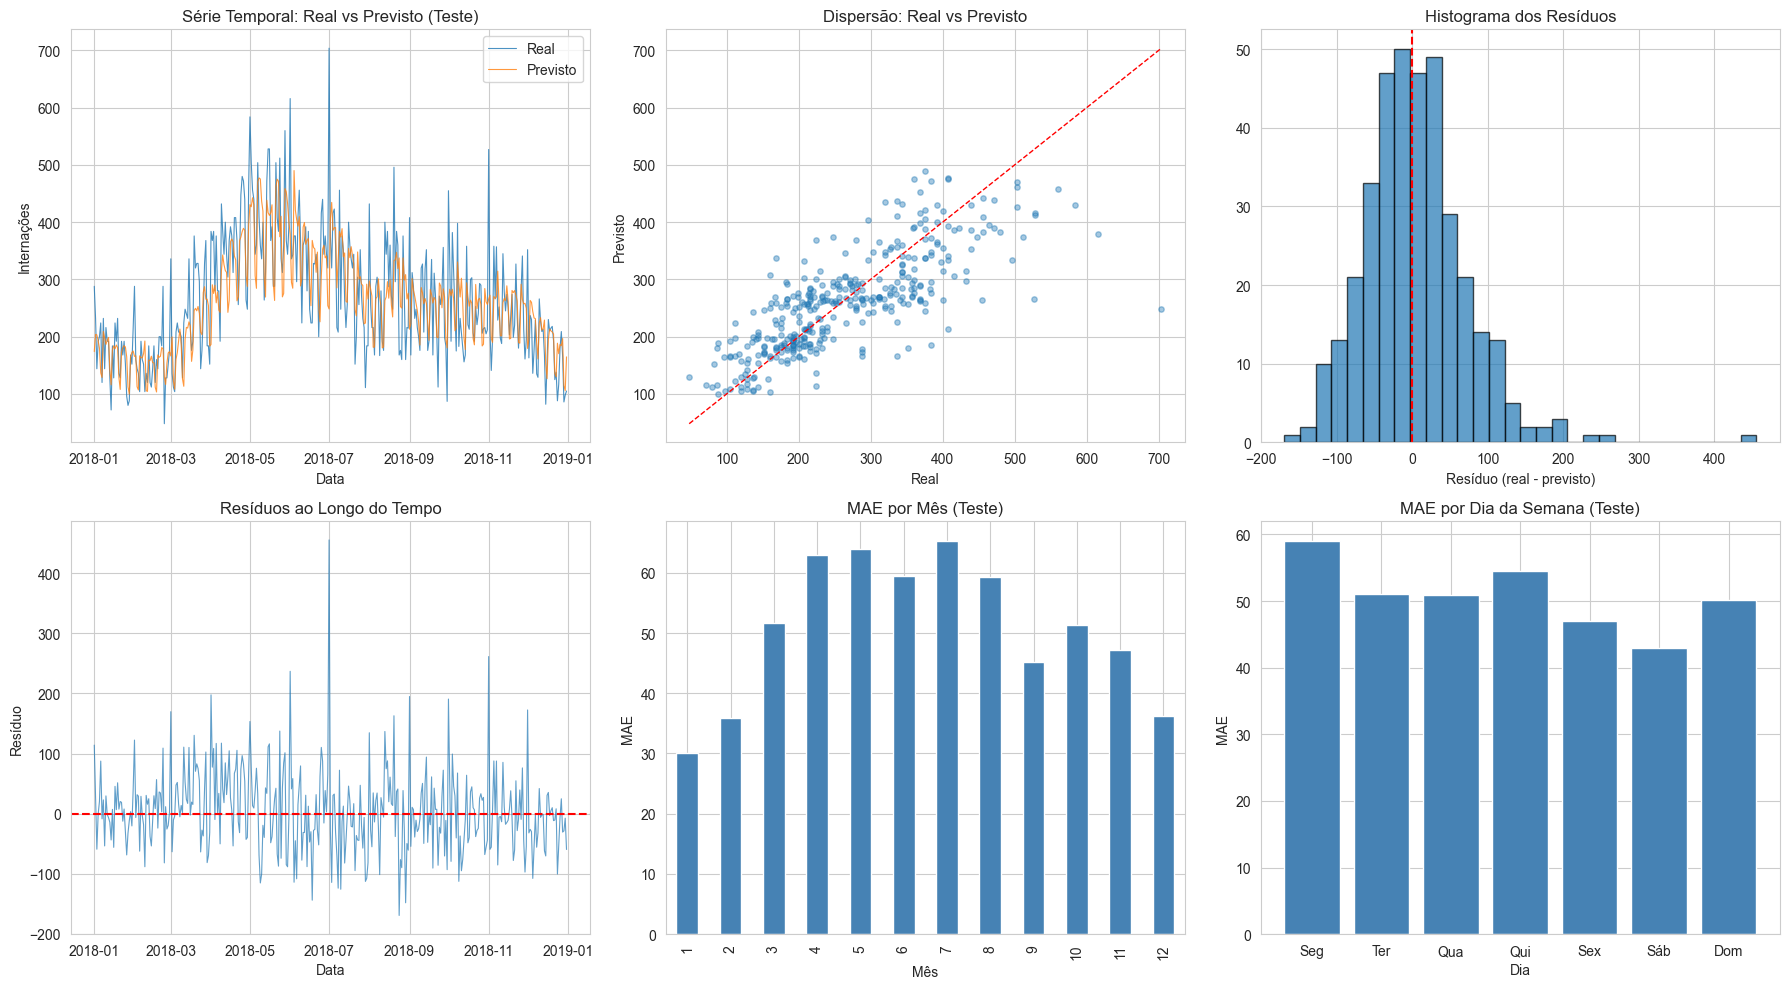

Gráficos de diagnóstico salvos.


In [12]:
residuals = y_test.values - pred_test_final

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Série temporal: real vs previsto
ax = axes[0, 0]
ax.plot(dates_test.values, y_test.values, label='Real', alpha=0.8, linewidth=0.8)
ax.plot(dates_test.values, pred_test_final, label='Previsto', alpha=0.8, linewidth=0.8)
ax.set_title('Série Temporal: Real vs Previsto (Teste)')
ax.set_xlabel('Data')
ax.set_ylabel('Internações')
ax.legend()

# 2. Dispersão: real vs previsto
ax = axes[0, 1]
ax.scatter(y_test.values, pred_test_final, alpha=0.4, s=15)
lims = [min(y_test.values.min(), pred_test_final.min()),
        max(y_test.values.max(), pred_test_final.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_title('Dispersão: Real vs Previsto')
ax.set_xlabel('Real')
ax.set_ylabel('Previsto')

# 3. Histograma dos resíduos
ax = axes[0, 2]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Histograma dos Resíduos')
ax.set_xlabel('Resíduo (real - previsto)')

# 4. Resíduos ao longo do tempo
ax = axes[1, 0]
ax.plot(dates_test.values, residuals, alpha=0.7, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Resíduos ao Longo do Tempo')
ax.set_xlabel('Data')
ax.set_ylabel('Resíduo')

# 5. Erro absoluto por mês
ax = axes[1, 1]
df_diag = pd.DataFrame({
    'data': dates_test.values,
    'residuo': residuals,
    'abs_error': np.abs(residuals)
})
df_diag['mes'] = pd.to_datetime(df_diag['data']).dt.month
df_diag.groupby('mes')['abs_error'].mean().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('MAE por Mês (Teste)')
ax.set_xlabel('Mês')
ax.set_ylabel('MAE')

# 6. Erro absoluto por dia da semana
ax = axes[1, 2]
df_diag['dia_semana'] = pd.to_datetime(df_diag['data']).dt.dayofweek
dias_nome = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
mae_dow = df_diag.groupby('dia_semana')['abs_error'].mean()
ax.bar(range(7), mae_dow.values, color='steelblue')
ax.set_xticks(range(7))
ax.set_xticklabels(dias_nome)
ax.set_title('MAE por Dia da Semana (Teste)')
ax.set_xlabel('Dia')
ax.set_ylabel('MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diagnostico_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos de diagnóstico salvos.')

## 13. Importância das Features

Análise com:
1. **`feature_importances_`** — impureza (MDI)
2. **Permutation importance** — avaliada no conjunto de teste

In [13]:
# Feature importances (MDI)
rf_model = final_pipeline.named_steps['rf']
importances_mdi = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_mdi = importances_mdi.sort_values(ascending=False)

# Permutation importance no teste
# Usa o pipeline completo (imputer + rf)
perm_result = permutation_importance(
    final_pipeline, X_test, y_test,
    n_repeats=15, random_state=SEED, scoring='neg_mean_absolute_error', n_jobs=-1
)
importances_perm = pd.Series(perm_result.importances_mean, index=feature_cols)
importances_perm = importances_perm.sort_values(ascending=False)

# Tabela consolidada
df_importance = pd.DataFrame({
    'MDI (Impureza)': importances_mdi,
    'Permutation': importances_perm
}).sort_values('Permutation', ascending=False)

print('=== Importância das Features ===')
display(df_importance.round(4))

=== Importância das Features ===


,MDI (Impureza),Permutation
so2_ma_150d_shift_21d,0.0111,0.0041
lag_3,0.0093,0.0033
no2_lag0,0.0095,0.0031
lag_28,0.0085,0.0027
lag_14,0.0485,0.0020
rolling_mean_30,0.0192,0.0017
rolling_std_7,0.0071,0.0017
lag_21,0.0098,0.0011
ur_ma_60d_shift_1d,0.0067,0.0008
o3_ma_120d_shift_1d,0.0069,0.0008


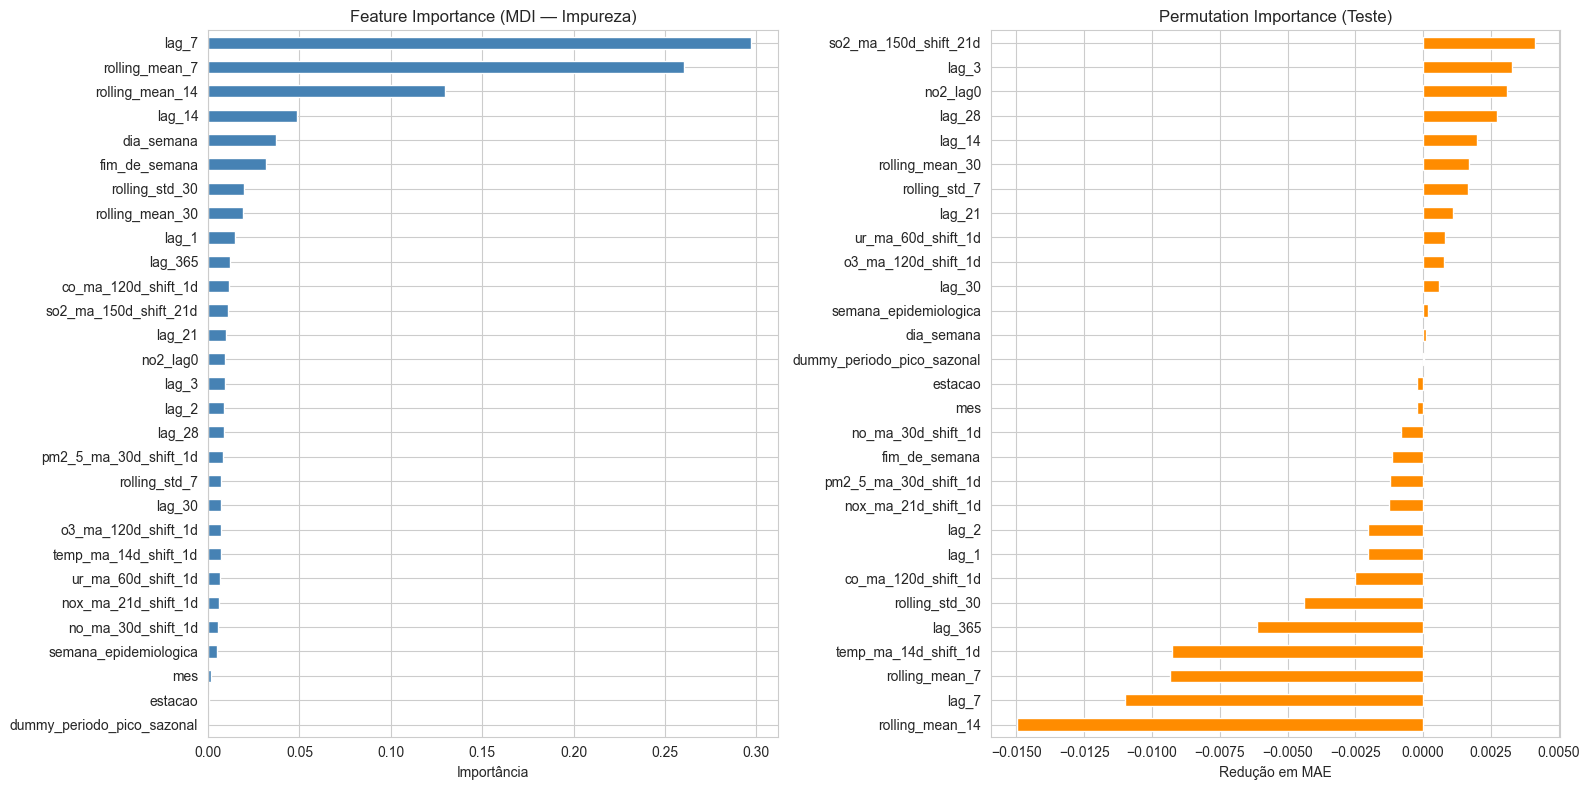

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# MDI
ax = axes[0]
importances_mdi.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (MDI — Impureza)')
ax.set_xlabel('Importância')

# Permutation
ax = axes[1]
importances_perm.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Permutation Importance (Teste)')
ax.set_xlabel('Redução em MAE')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

=== Importância por Grupo de Variáveis ===


,MDI (Impureza),Permutation
Grupo,,
Poluentes,0.0586,0.0022
Umidade,0.0067,0.0008
Calendário/Sazonalidade,0.0759,-0.0013
Temperatura,0.0068,-0.0093
Lags da série,0.4157,-0.0115
Médias/Desvios móveis,0.4364,-0.0254


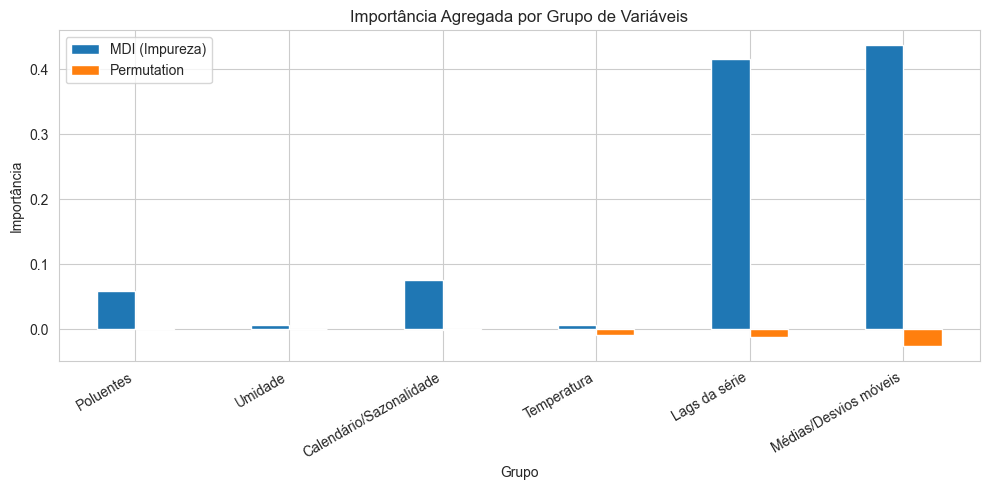

In [15]:
# Análise por grupo de variáveis
def classify_feature(name):
    """Classifica feature por grupo temático."""
    if name.startswith('lag_'):
        return 'Lags da série'
    if name.startswith('rolling_'):
        return 'Médias/Desvios móveis'
    if name in ['dia_semana', 'fim_de_semana', 'mes', 'semana_epidemiologica',
                'estacao', 'dummy_periodo_pico_sazonal']:
        return 'Calendário/Sazonalidade'
    if name.startswith(('o3', 'no_', 'no2', 'co_', 'so2', 'nox', 'pm')):
        return 'Poluentes'
    if name.startswith('temp'):
        return 'Temperatura'
    if name.startswith('ur'):
        return 'Umidade'
    return 'Outros'

df_importance['Grupo'] = df_importance.index.map(classify_feature)

group_importance = df_importance.groupby('Grupo')[['MDI (Impureza)', 'Permutation']].sum()
group_importance = group_importance.sort_values('Permutation', ascending=False)

print('=== Importância por Grupo de Variáveis ===')
display(group_importance.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
group_importance.plot(kind='bar', ax=ax)
ax.set_title('Importância Agregada por Grupo de Variáveis')
ax.set_ylabel('Importância')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'importancia_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Salvamento dos Artefatos Finais

In [17]:
# 1. Modelo final
joblib.dump(final_pipeline, OUTPUT_DIR / 'modelo_rf_final.joblib')
print(f'Modelo salvo: {OUTPUT_DIR / "modelo_rf_final.joblib"}')

# 2. Tabela de métricas
df_test_summary.to_csv(OUTPUT_DIR / 'metricas_teste.csv')
print(f'Métricas salvas: {OUTPUT_DIR / "metricas_teste.csv"}')

# 3. DataFrame com valores reais e previstos
df_predictions = pd.DataFrame({
    'data': dates_test.values,
    'real': y_test.values,
    'previsto': pred_test_final
})
df_predictions['residuo'] = df_predictions['real'] - df_predictions['previsto']
df_predictions.to_parquet(OUTPUT_DIR / 'previsoes_teste.parquet', index=False)
print(f'Previsões salvas: {OUTPUT_DIR / "previsoes_teste.parquet"}')

# 4. Importância das features
df_importance.to_csv(OUTPUT_DIR / 'importancia_features.csv')
print(f'Importância salva: {OUTPUT_DIR / "importancia_features.csv"}')

# 5. Metadata do modelo (para reprodutibilidade)
metadata = {
    'estrategia_alvo': best_strategy,
    'hiperparametros': search.best_params_,
    'periodo_treino': f'{dates_train.min().date()} a {dates_val.max().date()}',
    'periodo_teste': f'{dates_test.min().date()} a {dates_test.max().date()}',
    'n_features': len(feature_cols),
    'features': feature_cols,
    'metricas_teste': metrics_test,
}
if best_strategy == 'C: Log1p+Detrend':
    metadata['trend_coeffs'] = trend_coeffs_final.tolist()

joblib.dump(metadata, OUTPUT_DIR / 'metadata_modelo.joblib')
print(f'Metadata salvo: {OUTPUT_DIR / "metadata_modelo.joblib"}')

print('\n=== Todos os artefatos salvos com sucesso ===')
print(f'Diretório de saída: {OUTPUT_DIR.resolve()}')

Modelo salvo: ..\..\Data\GoldData\ModelResults\modelo_rf_final.joblib
Métricas salvas: ..\..\Data\GoldData\ModelResults\metricas_teste.csv
Previsões salvas: ..\..\Data\GoldData\ModelResults\previsoes_teste.parquet
Importância salva: ..\..\Data\GoldData\ModelResults\importancia_features.csv
Metadata salvo: ..\..\Data\GoldData\ModelResults\metadata_modelo.joblib

=== Todos os artefatos salvos com sucesso ===
Diretório de saída: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\GoldData\ModelResults


## 15. Resumo Final

Consolidação dos resultados para referência rápida.

In [16]:
print('=' * 70)
print('RESUMO FINAL DA PIPELINE DE MODELAGEM')
print('=' * 70)

print(f'\nModelo: Random Forest Regressor')
print(f'Estratégia de alvo: {best_strategy}')
print(f'Período de treino: {dates_train.min().date()} a {dates_val.max().date()} (retreino)')
print(f'Período de teste: {dates_test.min().date()} a {dates_test.max().date()}')
print(f'Número de features: {len(feature_cols)}')

print(f'\nHiperparâmetros finais:')
for k, v in best_params_clean.items():
    print(f'  {k}: {v}')

print(f'\nDesempenho no Teste (escala original):')
print(f'  MAE:   {metrics_test["MAE"]:.2f} internações')
print(f'  RMSE:  {metrics_test["RMSE"]:.2f} internações')
print(f'  R²:    {metrics_test["R²"]:.4f}')
print(f'  sMAPE: {metrics_test["sMAPE"]:.2f}%')

print(f'\nTop 5 features (Permutation Importance):')
for i, (feat, val) in enumerate(importances_perm.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

print(f'\nArtefatos salvos em: {OUTPUT_DIR.resolve()}')
print('=' * 70)

RESUMO FINAL DA PIPELINE DE MODELAGEM

Modelo: Random Forest Regressor
Estratégia de alvo: B: Log1p
Período de treino: 2012-12-31 a 2017-12-31 (retreino)
Período de teste: 2018-01-01 a 2018-12-31
Número de features: 29

Hiperparâmetros finais:
  max_depth: 40
  max_features: 0.7
  min_samples_leaf: 3
  min_samples_split: 13
  n_estimators: 459

Desempenho no Teste (escala original):
  MAE:   50.82 internações
  RMSE:  68.85 internações
  R²:    0.5877
  sMAPE: 19.76%

Top 5 features (Permutation Importance):
  1. so2_ma_150d_shift_21d: 0.0041
  2. lag_3: 0.0033
  3. no2_lag0: 0.0031
  4. lag_28: 0.0027
  5. lag_14: 0.0020

Artefatos salvos em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\GoldData\ModelResults
